In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np
import os


In [2]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.6.0


In [3]:
# Check and display the number of GPUs available for model training

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [4]:
# Define constants for image preprocessing, batching, and training parameters.
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50

In [5]:
# Loading the dataset
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    shuffle=True,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SIZE


)

Found 18160 files belonging to 10 classes.


In [6]:
# Retrieve and display the class names from the dataset for categorization.
class_names = dataset.class_names
class_names

['Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

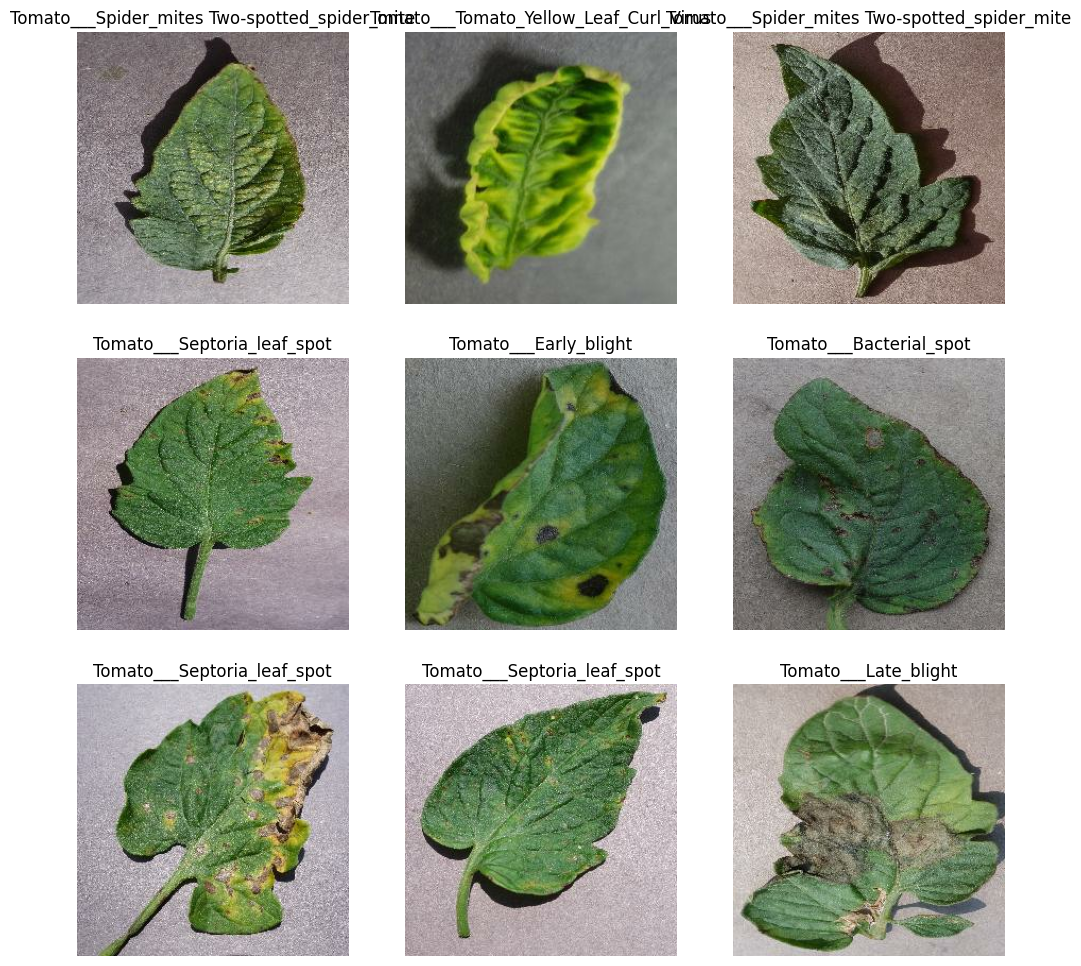

In [7]:
# Visualize a sample of the images from the dataset along with their labels.

plt.figure(figsize=(12,12))
for image_batch, label_batch in dataset.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.axis("off")
        plt.title(class_names[label_batch[i]])

In [8]:
# Display the total number of batches in the dataset.
len(dataset)

568

In [9]:
# Function to split the dataset into training, validation, and test sets.

def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=1000):
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12) # Shuffle the dataset for randomness in training
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [10]:
# Split the dataset into training, validation, and test partitions.

train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [11]:
# Display the number of batches in the training dataset.
len(train_ds)


454

In [12]:
# Display the number of batches in the validation dataset.
len(val_ds)

56

In [13]:
# Display the number of batches in the testing dataset.
len(test_ds)

58

In [14]:
# Apply caching, shuffling, and prefetching to the datasets for better performance during training.

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [15]:
# Define the preprocessing pipeline that resizes and rescales images to a uniform format.

resize_and_rescale = tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.experimental.preprocessing.Rescaling(1.0/255)
])


In [16]:
# Define the data augmentation pipeline to apply random transformations to the images.

data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2),
    layers.experimental.preprocessing.RandomZoom(0.2),
    layers.experimental.preprocessing.RandomContrast(0.1),
    
])

In [17]:
# Build the model architecture by stacking convolutional, pooling, and dense layers.

input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = len(class_names)
model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size = (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size = (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
    
    
])
model.build(input_shape=input_shape)

In [18]:
# Summarize the model architecture to display the number of parameters and layer configurations.

model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequential (Sequential)      (32, 256, 256, 3)         0         
_________________________________________________________________
sequential_1 (Sequential)    (32, 256, 256, 3)         0         
_________________________________________________________________
conv2d (Conv2D)              (32, 254, 254, 32)        896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (32, 127, 127, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (32, 125, 125, 64)        18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (32, 62, 62, 64)          0         
_________________________________________________________________
conv2d_2 (Conv2D)            (32, 60, 60, 64)         

In [19]:
# Compile the model with the Adam optimizer and sparse categorical crossentropy loss function.

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']

)

In [20]:
# Train the model on the training dataset and validate on the validation dataset.

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=val_ds
)

Epoch 1/50
454/454 [==============================] - 102s 171ms/step - loss: 1.5659 - accuracy: 0.4649 - val_loss: 1.2974 - val_accuracy: 0.5636
Epoch 2/50
454/454 [==============================] - 61s 135ms/step - loss: 1.0738 - accuracy: 0.6313 - val_loss: 0.9747 - val_accuracy: 0.6814
Epoch 3/50
454/454 [==============================] - 36s 79ms/step - loss: 0.7933 - accuracy: 0.7262 - val_loss: 1.3781 - val_accuracy: 0.6367
Epoch 4/50
454/454 [==============================] - 36s 79ms/step - loss: 0.6142 - accuracy: 0.7827 - val_loss: 0.6659 - val_accuracy: 0.7757
Epoch 5/50
454/454 [==============================] - 37s 80ms/step - loss: 0.5128 - accuracy: 0.8211 - val_loss: 1.1240 - val_accuracy: 0.7121
Epoch 6/50
454/454 [==============================] - 41s 89ms/step - loss: 0.4369 - accuracy: 0.8470 - val_loss: 1.2468 - val_accuracy: 0.6948
Epoch 7/50
454/454 [==============================] - 38s 84ms/step - loss: 0.3762 - accuracy: 0.8698 - val_loss: 1.0470 - val_accura

In [21]:
# Evaluate the model performance on the test dataset.

scores = model.evaluate(test_ds)

58/58 [==============================] - 25s 96ms/step - loss: 0.1797 - accuracy: 0.9407


In [22]:
# Calculate precision, recall, and F1 score for the model's predictions on the test set.

from sklearn.metrics import precision_score, recall_score, f1_score

# Initialize lists to store true and predicted labels
y_true = []
y_pred = []

# Iterate over the test dataset to collect true and predicted labels
for images, labels in test_ds:
    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = labels.numpy()
    
    y_pred.extend(predicted_classes)
    y_true.extend(true_classes)

# Convert lists to numpy arrays for metric calculation
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute the metrics
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Precision: 0.9473392512498754
Recall: 0.9407327586206896
F1 Score: 0.9419617704824785


In [23]:
# Store the training and validation accuracy and loss for visualization.

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

Text(0.5, 1.0, 'Training and Validation Loss')

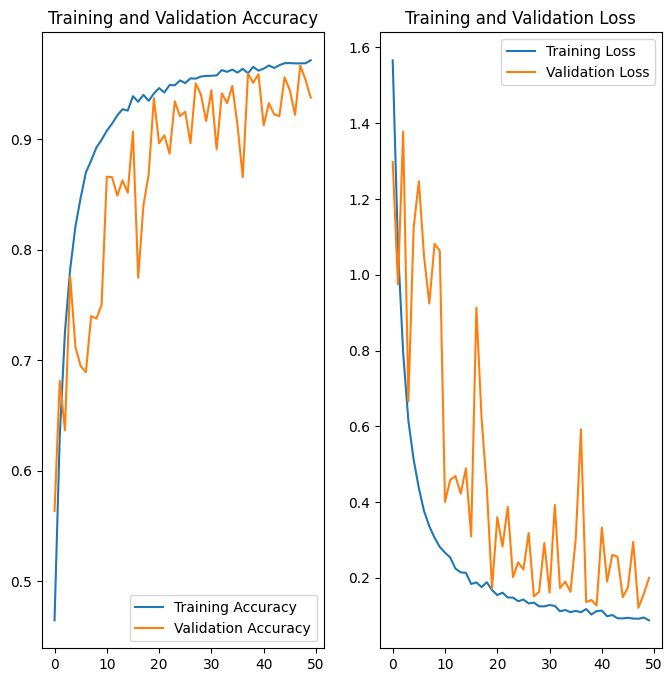

In [24]:
# Visualize the training and validation accuracy and loss over the epochs.

plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), acc, label="Training Accuracy")
plt.plot(range(EPOCHS), val_acc, label="Validation Accuracy")
plt.legend(loc='lower right')
plt.title("Training and Validation Accuracy")

plt.subplot(1,2,2)
plt.plot(range(EPOCHS), loss, label="Training Loss")
plt.plot(range(EPOCHS), val_loss, label="Validation Loss")
plt.legend(loc='upper right')
plt.title("Training and Validation Loss")

first image to predict
actual label:  Tomato___Late_blight
predicted label:  Tomato___Late_blight


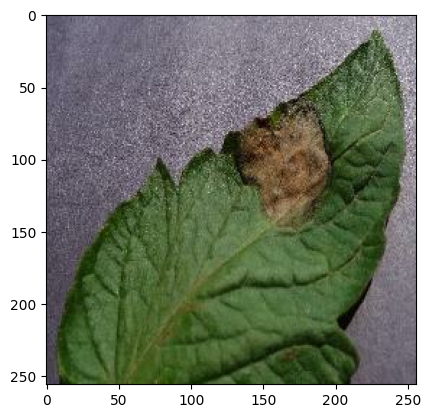

In [28]:
# Display a sample image along with its predicted label for visual inspection.

for images_batch, labels_batch in test_ds.take(1):
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label: ", class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label: ",class_names[np.argmax(batch_prediction[0])])

In [29]:
# Save the trained model with versioning to manage different model iterations.
models_dir = "../models"  # Adjust the path as necessary

if not os.path.exists(models_dir):
    os.makedirs(models_dir)

model_name = "model_version"

model_version = max(
    [int(i.split('_v')[-1].split('.')[0]) for i in os.listdir(models_dir) if i.startswith(model_name)] + [0]
) + 1

model_save_path = f"{models_dir}/{model_name}_v{model_version}.keras"
model.save(model_save_path)
